# 09 · Residual diagnostics (ACF / PACF)

Computes ACF/PACF on the out-of-fold residuals for Random Forest and XGBoost, on both the acoustic + GRU and acoustic (reduced) + GRU feature sets from notebook 08.

### Before running

Notebook 08 (or notebooks 03 + 07 + one of 04/05) must have run, producing
`merged_features_with_pred.csv`. If notebook 08 already wrote `runs/folds_k5_seed*.json`, this
notebook reuses those folds so the CV split is identical to notebook 08's; otherwise it writes its
own with the same seeded logic.

In [ ]:
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import wilcoxon

warnings.filterwarnings("ignore")

BASE      = f"/scratch/{os.environ.get('USER','username')}/capstone"
PRED_CSV  = os.path.join(BASE, "merged_features_with_pred.csv")
RUNS      = os.path.join(BASE, "runs"); os.makedirs(RUNS, exist_ok=True)
FIG_DIR   = os.path.join(BASE, "figures", "residuals"); os.makedirs(FIG_DIR, exist_ok=True)

TARGET   = "shannon_rare_no_anchoa"
PRED_COL = "shannon_pred_gru"
K_FOLDS  = 5
SEEDS    = [0, 1, 2, 3, 4]

ACOUSTIC = [
    # amplitude and envelope
    "RMS", "Floor", "Dynamics",
    # transients and events
    "Click_Count", "Click_Frequency",
    "Event_Count", "Mean_Duration", "Max_Duration",
    # spectral shape
    "centroid", "bandwidth", "rolloff",
    # soundscape indices
    "aci", "ADI", "entropy",
    # band energy fractions
    "band_100_500", "band_500_1000", "band_1000_2000",
    # power spectrum, 100 Hz bins across 100-2000 Hz
    "pwr_0100_0200", "pwr_0200_0300", "pwr_0300_0400", "pwr_0400_0500",
    "pwr_0500_0600", "pwr_0600_0700", "pwr_0700_0800", "pwr_0800_0900",
    "pwr_0900_1000", "pwr_1000_1100", "pwr_1100_1200", "pwr_1200_1300",
    "pwr_1300_1400", "pwr_1400_1500", "pwr_1500_1600", "pwr_1600_1700",
    "pwr_1700_1800", "pwr_1800_1900", "pwr_1900_2000",
    # measured on the unfiltered signal
    "zcr_fullband",
]
ACOUSTIC_REDUCED = [
    "RMS", "zcr_fullband",
    "band_100_500", "band_500_1000", "band_1000_2000",
]

print(f"acoustic block: {len(ACOUSTIC)} features (37 expected)")
assert len(ACOUSTIC) == 37, "acoustic block no longer matches notebook 08 -- check for edits upstream"


acoustic block: 37 features (37 expected)


## Aggregate to recording level

Same aggregation as notebook 08 (acoustic columns averaged within a recording; target and GRU
prediction are already constant within a recording), plus `date` and `collection` (day/night), which
the All/Day/Night split below needs.

In [ ]:
if not os.path.exists(PRED_CSV):
    raise SystemExit("merged_features_with_pred.csv not found. Run 07_gru_predictions.ipynb first.")
D = pd.read_csv(PRED_CSV)

missing = [c for c in ACOUSTIC + [TARGET, PRED_COL, "date", "collection"] if c not in D.columns]
if missing:
    raise SystemExit(f"columns absent from the feature table: {missing}")

agg = {c: "mean" for c in ACOUSTIC}
agg.update({c: "first" for c in [TARGET, PRED_COL, "date", "collection"]})
R = D.groupby("recording_key").agg(agg).reset_index()

R["date"] = pd.to_datetime(R["date"])
R = R.sort_values(["date", "recording_key"]).reset_index(drop=True)

constant = [c for c in ACOUSTIC if R[c].nunique(dropna=False) <= 1]
if constant:
    print(f"dropping {len(constant)} constant column(s): {constant}")
ACOUSTIC = [c for c in ACOUSTIC if c not in constant]
ACOUSTIC_REDUCED = [c for c in ACOUSTIC_REDUCED if c not in constant]

FEATURE_SETS = {
    "acoustic + GRU":           ACOUSTIC + [PRED_COL],
    "acoustic (reduced) + GRU": ACOUSTIC_REDUCED + [PRED_COL],
}
MODELS = ["random forest", "xgboost"]

print(f"{len(R)} recordings, {R['date'].min().date()} to {R['date'].max().date()}")
for k, v in FEATURE_SETS.items():
    print(f"  {k:26s} {len(v):3d} features")


72 recordings, 2025-05-27 to 2026-05-27
  acoustic + GRU              38 features
  acoustic (reduced) + GRU     6 features


## Shared folds

Reuses notebook 08's fold assignments (`runs/folds_k5_seed*.json`) when present, so the CV split
here is identical to the one the reported R²/MAE numbers came from. If they're missing, the same
seeded shuffle-and-split used in notebooks 05/08 is applied and written to disk, keyed by
`recording_key` rather than row position so it doesn't depend on run order.

In [3]:
def load_or_make_folds(seed, k=K_FOLDS, verbose=True):
    p = os.path.join(RUNS, f"folds_k{k}_seed{seed}.json")
    keys = R["recording_key"].tolist()
    if os.path.exists(p):
        d = json.load(open(p))["folds"]
        missing = [r for r in keys if r not in d]
        if missing:
            raise SystemExit(f"{os.path.basename(p)} does not cover: {missing[:3]}")
        return np.array([d[r] for r in keys], dtype=int)
    rng = np.random.default_rng(seed)
    idx = np.arange(len(keys)); rng.shuffle(idx)
    assign = {}
    for f, part in enumerate(np.array_split(idx, k)):
        for i in part:
            assign[keys[i]] = f
    json.dump(dict(k=k, seed=seed, n_recordings=len(keys), folds=assign),
              open(p, "w"), indent=2)
    if verbose:
        print(f"    wrote shared fold file -> {os.path.basename(p)}")
    return np.array([assign[k_] for k_ in keys], dtype=int)

fold_of = {s: load_or_make_folds(s) for s in SEEDS}
sizes = pd.Series(fold_of[SEEDS[0]]).value_counts().sort_index().tolist()
print(f"fold sizes (seed {SEEDS[0]}): {sizes}")


fold sizes (seed 0): [15, 15, 14, 14, 14]


## Out-of-fold residuals

Same model configurations as notebook 08. For each model / feature set, every recording gets one
out-of-fold prediction per seed; the 5 seeds are averaged to a single prediction per recording before
taking the residual (`actual - predicted`), matching how notebook 07 built `shannon_pred_gru`.

In [4]:
def build(model, seed):
    if model == "xgboost":
        return XGBRegressor(n_estimators=400, max_depth=3, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                            random_state=seed, n_jobs=4, verbosity=0)
    return RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_leaf=2,
                                 max_features="sqrt", random_state=seed, n_jobs=4)

def oof_predict(model, cols, seed):
    X = R[cols].to_numpy(dtype=float)
    y = R[TARGET].to_numpy(dtype=float)
    folds = fold_of[seed]
    oof = np.full(len(y), np.nan)
    for f in range(K_FOLDS):
        te = folds == f
        m = build(model, seed).fit(X[~te], y[~te])
        oof[te] = m.predict(X[te])
    return oof

y = R[TARGET].to_numpy(dtype=float)
RESID = {}
for model in MODELS:
    for fname, cols in FEATURE_SETS.items():
        oof_seeds = np.vstack([oof_predict(model, cols, s) for s in SEEDS])
        RESID[(model, fname)] = y - oof_seeds.mean(axis=0)
    print(f"{model} complete")


random forest complete
xgboost complete


## All / Day / Night series

Exactly notebook 07's `obs_series`: for the combined ("All") series, a date with both a day and a
night session contributes one point (the two residuals averaged); Day and Night are each session
type alone. This is what the ACF/PACF, weekly check, Ljung-Box, and Wilcoxon sections below all run
on.

In [5]:
def obs_series(rec, resid_col, which):
    """Residuals in time order. `which` is All, Day or Night."""
    d = rec.dropna(subset=[resid_col])
    if which == "All":
        return d.groupby("date")[resid_col].mean().sort_index()
    return d[d["collection"] == which.lower()].set_index("date")[resid_col].sort_index()

COLS = {"All": "#1F7A8C", "Day": "#BA7517", "Night": "#534AB7"}
MONTH_LAGS = [(4, "~1 mo"), (8, "~2 mo"), (13, "~3 mo")]
COMBOS = [(m, f) for m in MODELS for f in FEATURE_SETS]

REC_BASE = R[["recording_key", "date", "collection"]].copy()

def combo_series(model, fname):
    rec = REC_BASE.copy()
    rec["residual"] = RESID[(model, fname)]
    return {w: obs_series(rec, "residual", w) for w in ["All", "Day", "Night"]}, rec

print(f"{'model':14s} {'features':26s} {'series':6s} {'n':>4s} {'mean':>9s} {'sd':>8s}")
for model, fname in COMBOS:
    series, _ = combo_series(model, fname)
    for w, s in series.items():
        print(f"{model:14s} {fname:26s} {w:6s} {len(s):>4d} {s.mean():>+9.4f} {s.std():>8.4f}")


model          features                   series    n      mean       sd
random forest  acoustic + GRU             All      42   -0.0003   0.3259
random forest  acoustic + GRU             Day      33   -0.0055   0.3052
random forest  acoustic + GRU             Night    39   +0.0277   0.3671
random forest  acoustic (reduced) + GRU   All      42   -0.0008   0.2986
random forest  acoustic (reduced) + GRU   Day      33   -0.0313   0.2783
random forest  acoustic (reduced) + GRU   Night    39   +0.0480   0.3562
xgboost        acoustic + GRU             All      42   -0.0069   0.3245
xgboost        acoustic + GRU             Day      33   +0.0049   0.3313
xgboost        acoustic + GRU             Night    39   +0.0027   0.3692
xgboost        acoustic (reduced) + GRU   All      42   +0.0022   0.2934
xgboost        acoustic (reduced) + GRU   Day      33   -0.0245   0.2892
xgboost        acoustic (reduced) + GRU   Night    39   +0.0450   0.3722


## Residuals over time

One figure per model / feature set: the combined series on top, day and night overlaid below.

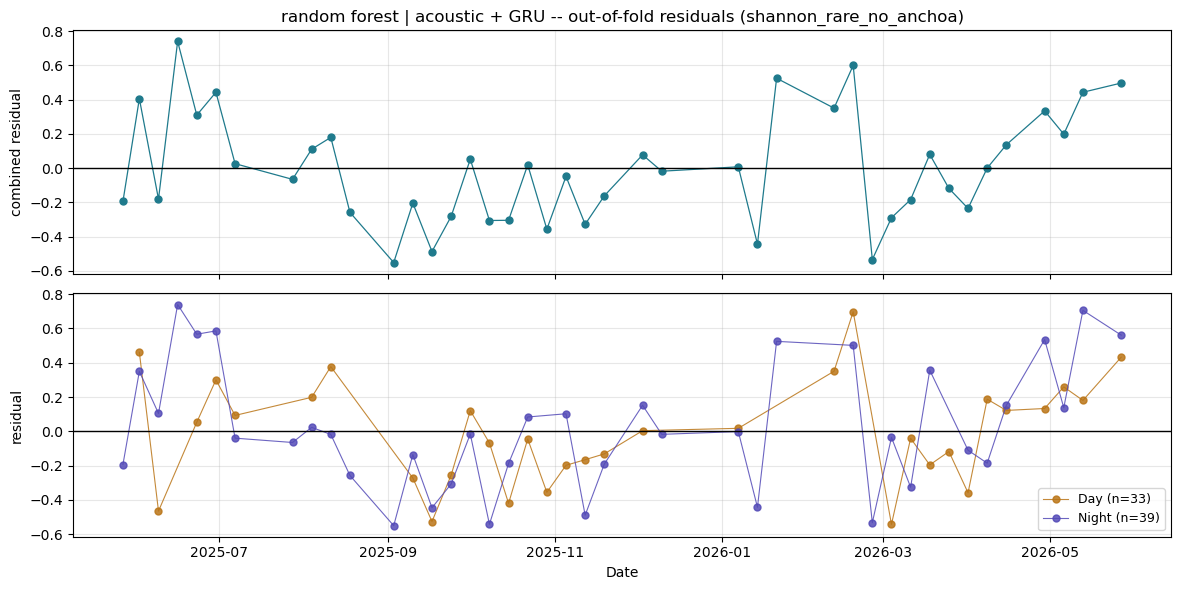

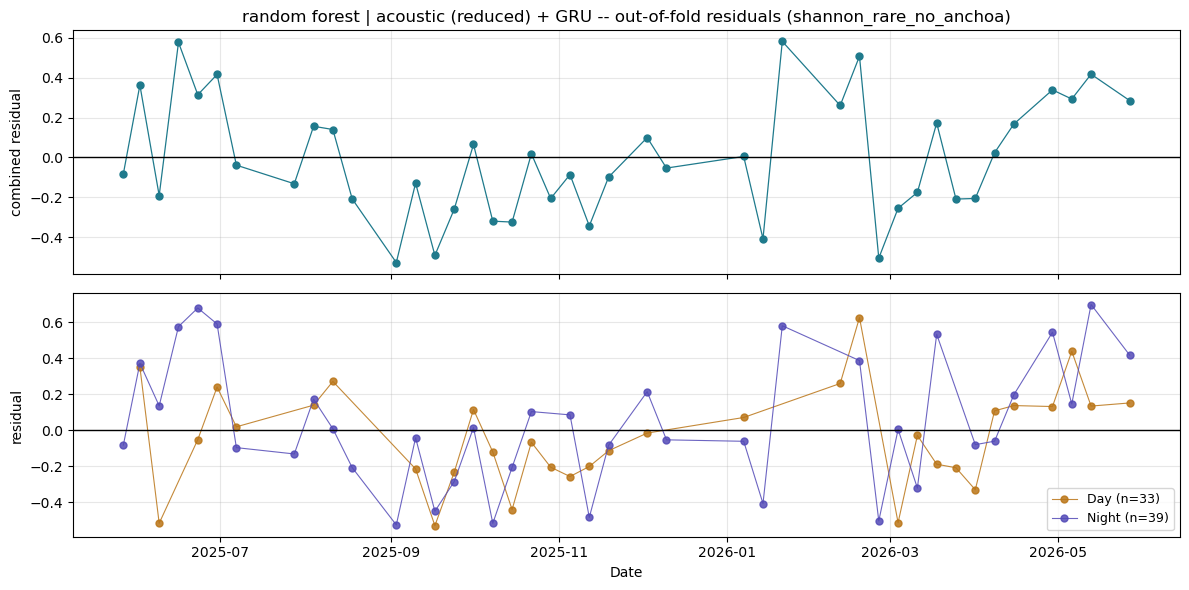

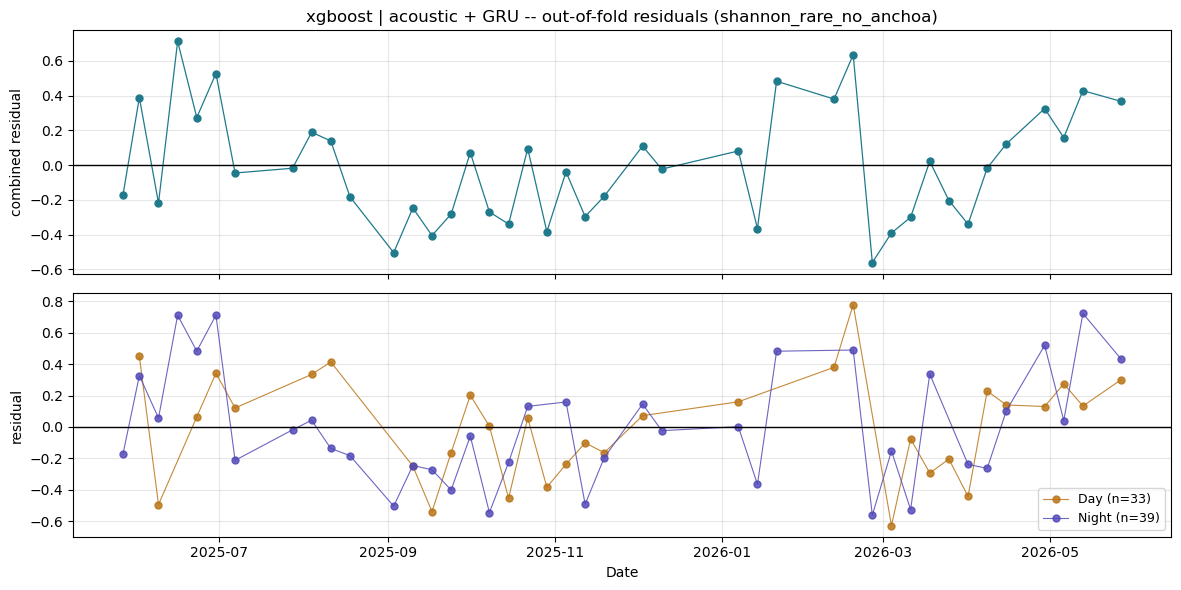

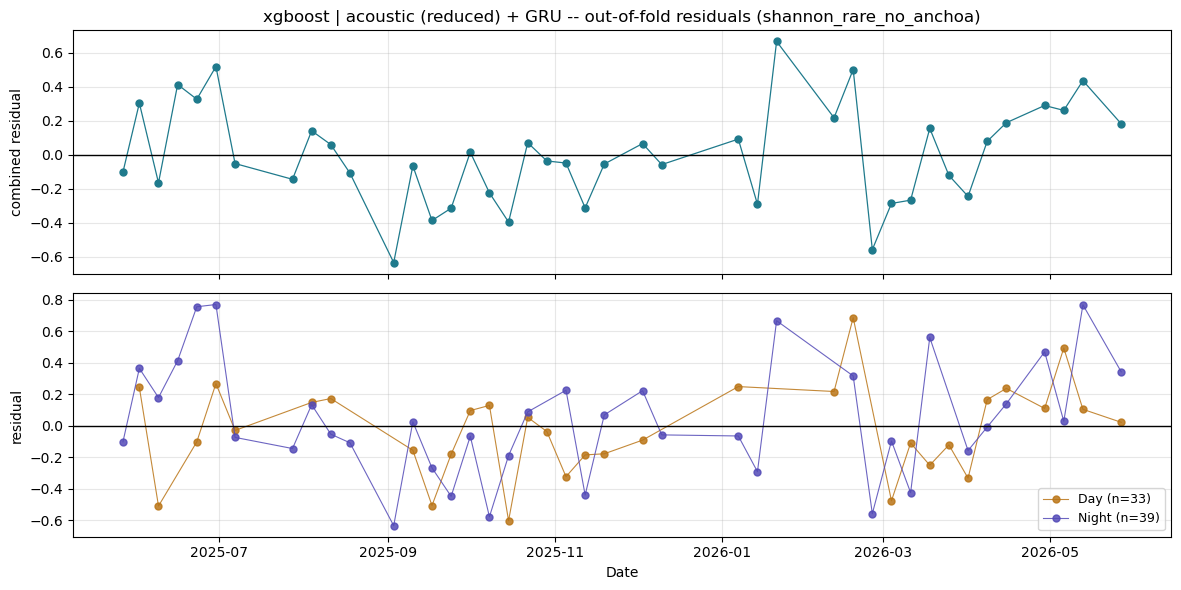

In [6]:
for model, fname in COMBOS:
    series, _ = combo_series(model, fname)
    tag = f"{model.replace(' ', '_')}_{fname.replace(' ', '_').replace('(', '').replace(')', '')}"
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    s = series["All"]
    axes[0].plot(s.index, s.values, "o-", ms=5, lw=0.9, color=COLS["All"])
    axes[0].axhline(0, color="k", lw=1); axes[0].grid(alpha=0.3)
    axes[0].set_ylabel("combined residual")
    axes[0].set_title(f"{model} | {fname} -- out-of-fold residuals ({TARGET})", fontsize=12)
    for w in ["Day", "Night"]:
        s = series[w]
        if len(s):
            axes[1].plot(s.index, s.values, "o-", ms=5, lw=0.8, color=COLS[w],
                        alpha=0.85, label=f"{w} (n={len(s)})")
    axes[1].axhline(0, color="k", lw=1); axes[1].grid(alpha=0.3)
    axes[1].set_ylabel("residual"); axes[1].set_xlabel("Date"); axes[1].legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"residuals_over_time_{tag}.png"), dpi=150, bbox_inches="tight")
    plt.show()


## Autocorrelation (ACF / PACF)

ACF on the left, PACF on the right, one row per series (All / Day / Night, dropped if fewer than 10
points). Lags run to half the series length. The shaded band is the 95% interval expected under
white noise; bars reaching outside it indicate real autocorrelation. Dotted lines mark roughly one,
two and three months. **The `acoustic + GRU` rows are what the professor asked to see.**

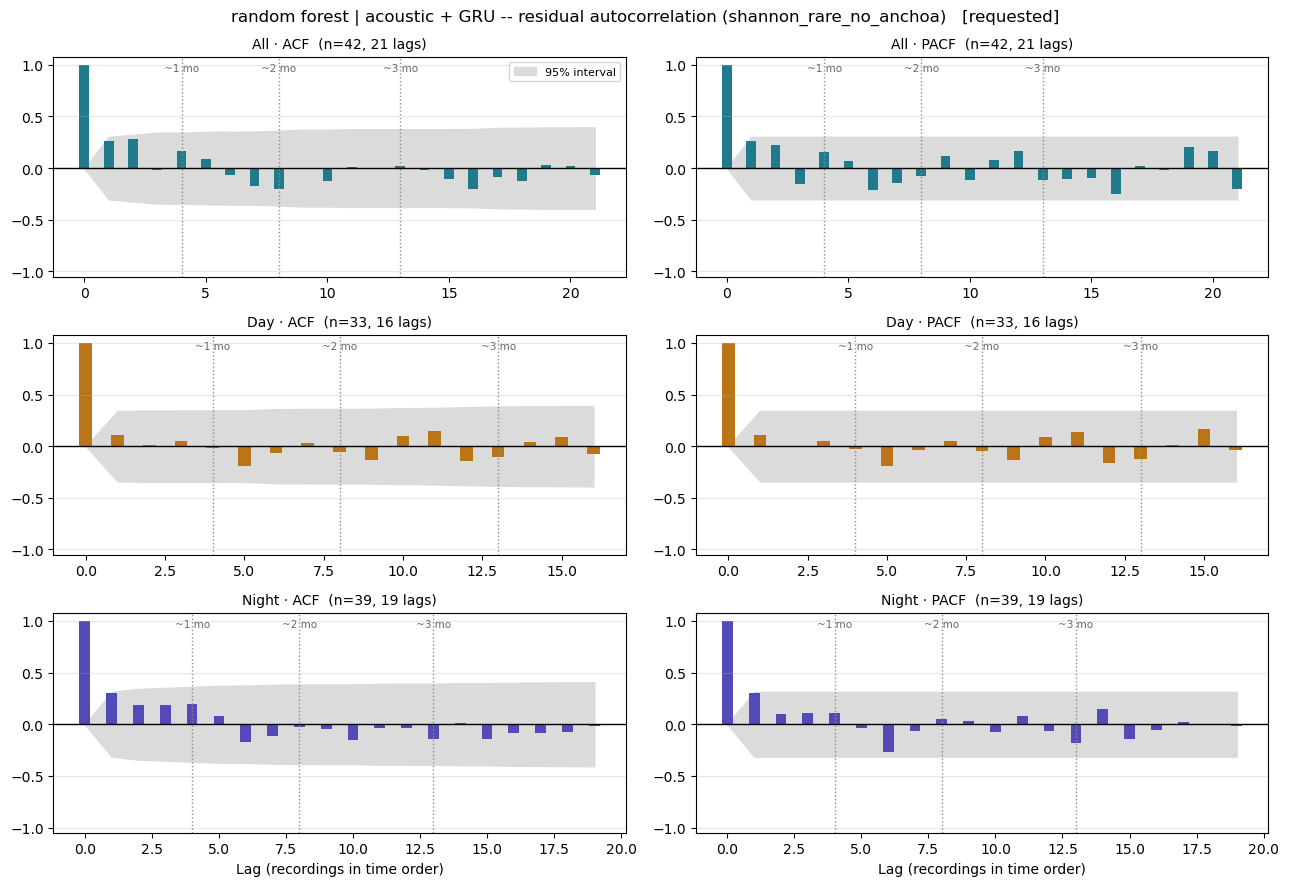

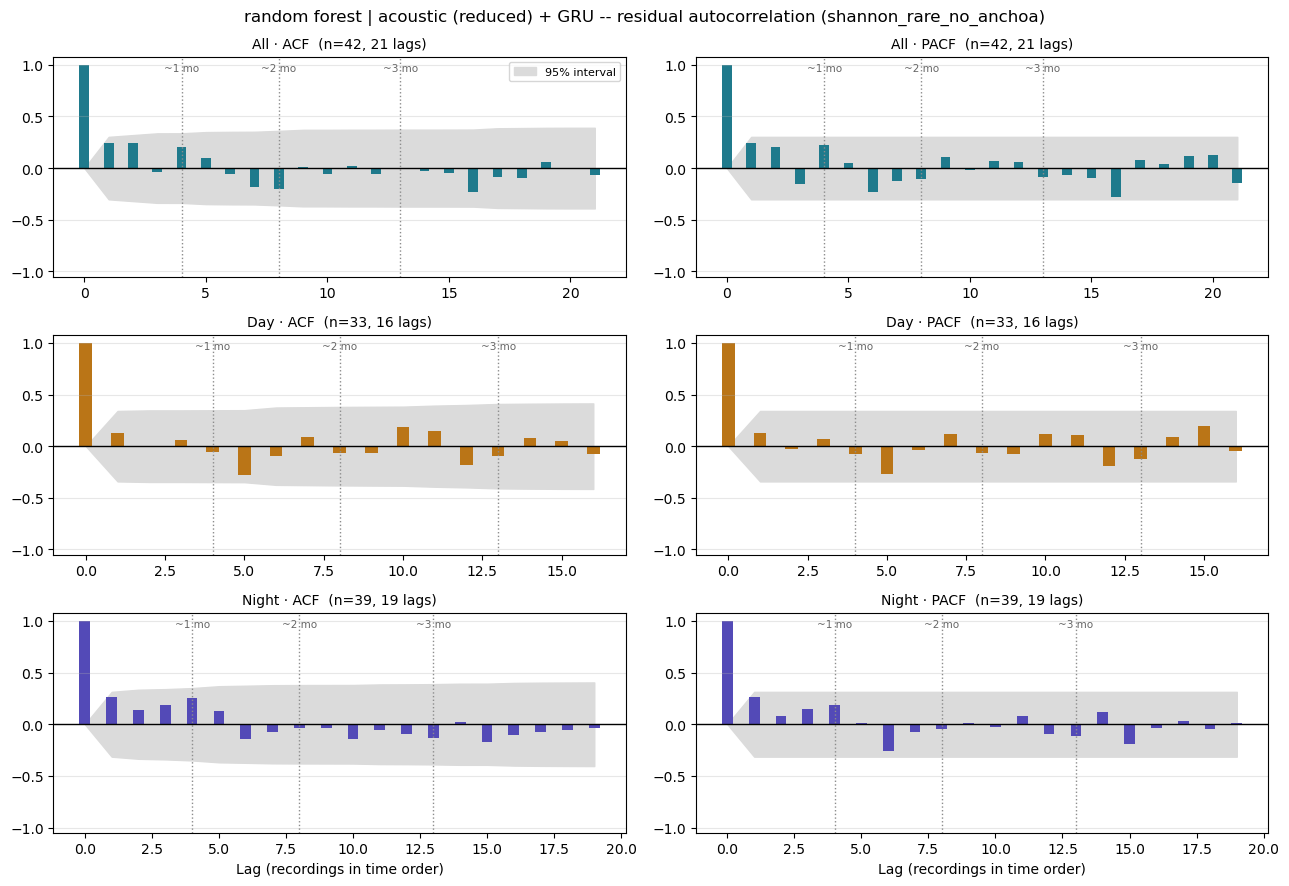

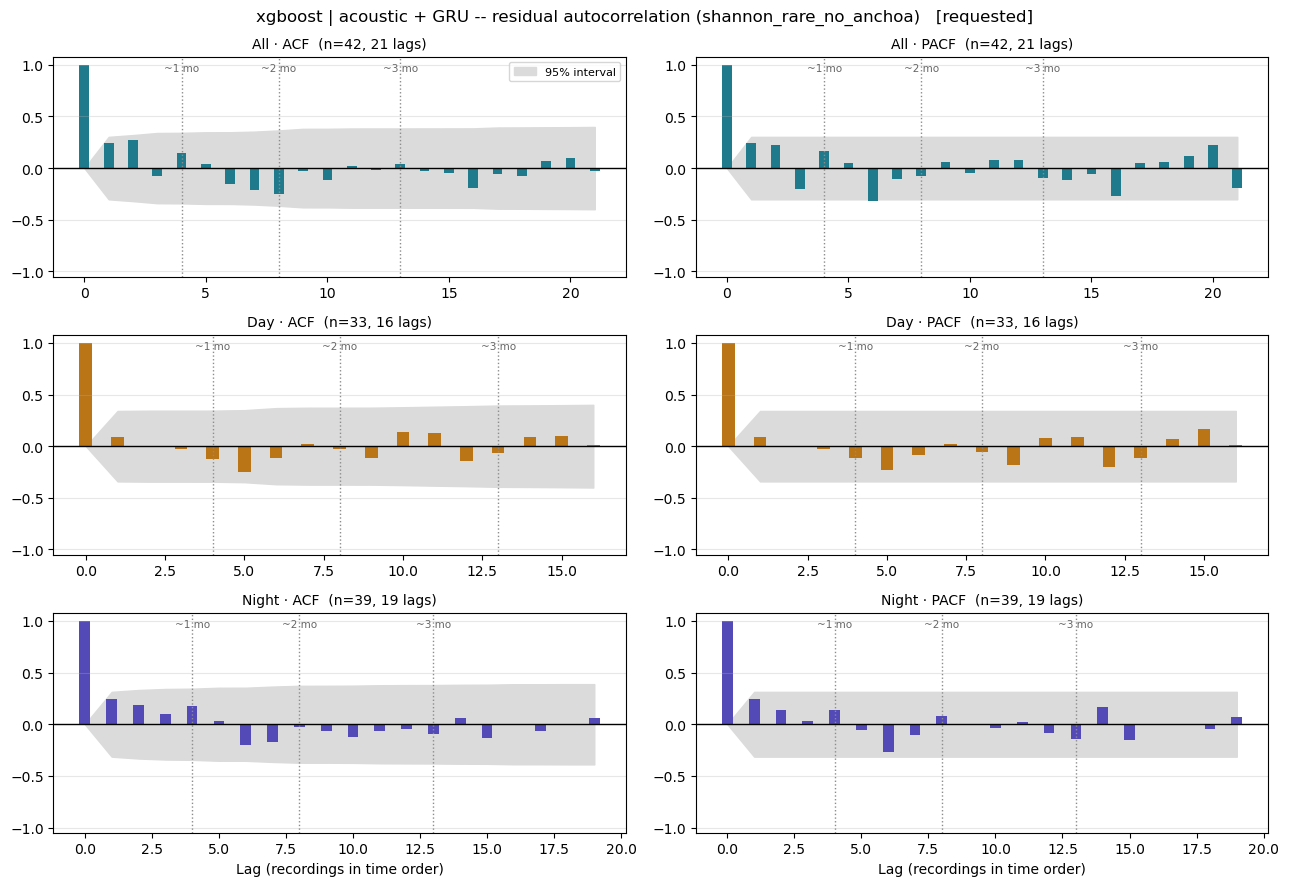

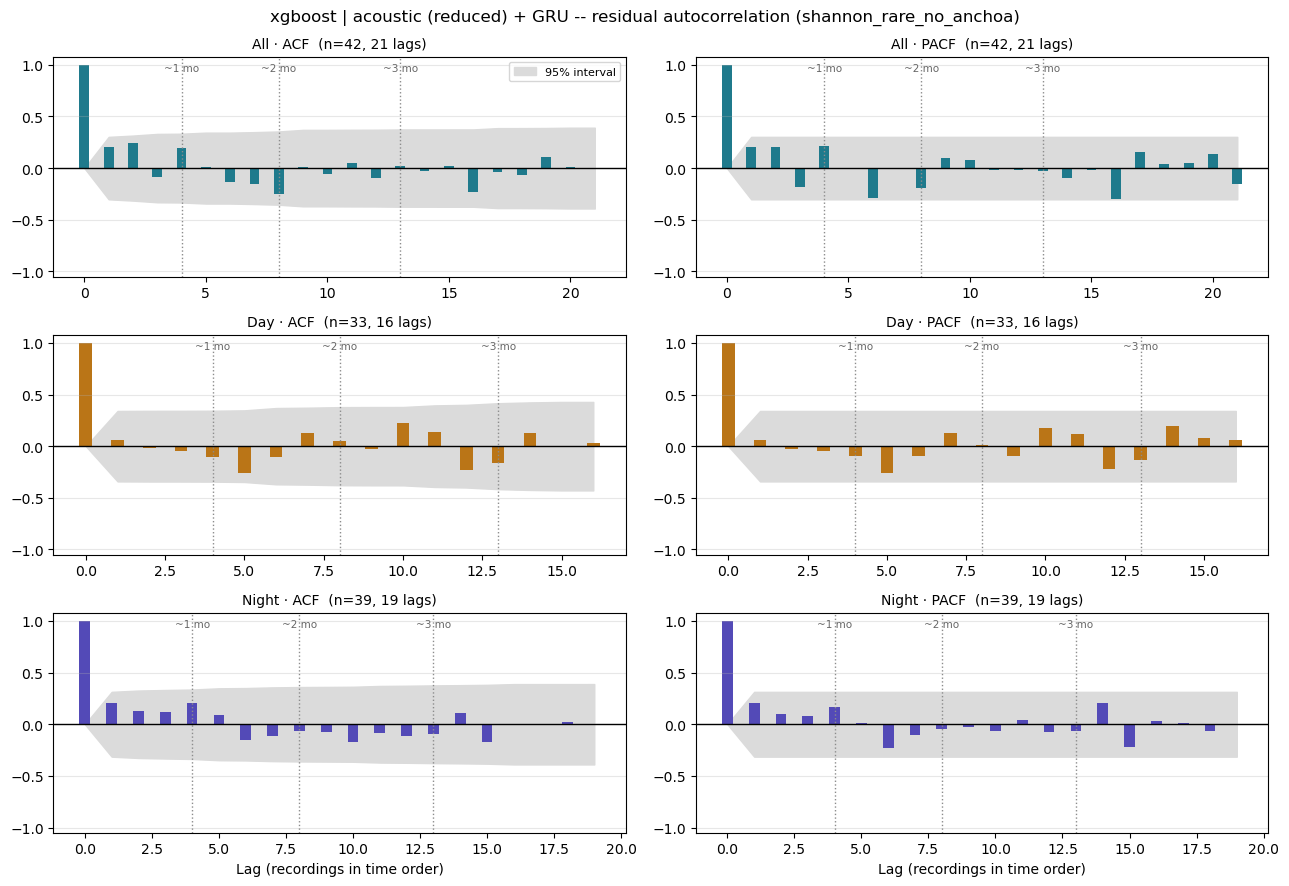

In [7]:
def acf_ci(x, nlags, partial=False, alpha=0.05):
    x = np.asarray(x, float)
    if partial:
        return pacf(x, nlags=nlags, alpha=alpha, method="ywm")
    return acf(x, nlags=nlags, alpha=alpha, fft=False)

for model, fname in COMBOS:
    series, _ = combo_series(model, fname)
    tag = f"{model.replace(' ', '_')}_{fname.replace(' ', '_').replace('(', '').replace(')', '')}"
    rows = [w for w in ["All", "Day", "Night"] if len(series[w]) >= 10]
    fig, axes = plt.subplots(len(rows), 2, figsize=(13, 3.0 * len(rows)), squeeze=False)
    for r, w in enumerate(rows):
        s = series[w]; n = len(s)
        nlags = max(4, min(n // 2, n - 2))
        for c, partial in [(0, False), (1, True)]:
            ax = axes[r, c]
            v, ci = acf_ci(s.values, nlags, partial)
            lags = np.arange(len(v))
            ax.fill_between(lags, ci[:, 0] - v, ci[:, 1] - v, color="0.86", zorder=0,
                            label="95% interval")
            ax.bar(lags, v, width=0.4, color=COLS[w])
            for L, lab in MONTH_LAGS:
                if L < len(v):
                    ax.axvline(L, color="0.55", ls=":", lw=1)
                    ax.text(L, 1.02, lab, fontsize=7.5, color="0.4", ha="center", va="top")
            ax.axhline(0, color="k", lw=1)
            ax.set_ylim(-1.05, 1.08); ax.grid(axis="y", alpha=0.3)
            ax.set_title(f"{w} \u00b7 {'PACF' if partial else 'ACF'}  (n={n}, {nlags} lags)", fontsize=10)
            if r == len(rows) - 1: ax.set_xlabel("Lag (recordings in time order)")
            if r == 0 and c == 0: ax.legend(fontsize=8, loc="upper right")
    fig.suptitle(f"{model} | {fname} -- residual autocorrelation ({TARGET})"
                + ("   [requested]" if fname == "acoustic + GRU" else ""), fontsize=12)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"acf_pacf_{tag}.png"), dpi=150, bbox_inches="tight")
    plt.show()


In [10]:
print(f"figures: {os.path.relpath(FIG_DIR, BASE)}/")
for f in sorted(os.listdir(FIG_DIR)):
    print(f"  {f}")


figures: figures/residuals/
  acf_pacf_random_forest_acoustic_+_GRU.png
  acf_pacf_random_forest_acoustic_reduced_+_GRU.png
  acf_pacf_xgboost_acoustic_+_GRU.png
  acf_pacf_xgboost_acoustic_reduced_+_GRU.png
  acf_weekly_random_forest_acoustic_+_GRU.png
  acf_weekly_random_forest_acoustic_reduced_+_GRU.png
  acf_weekly_xgboost_acoustic_+_GRU.png
  acf_weekly_xgboost_acoustic_reduced_+_GRU.png
  residuals_over_time_random_forest_acoustic_+_GRU.png
  residuals_over_time_random_forest_acoustic_reduced_+_GRU.png
  residuals_over_time_xgboost_acoustic_+_GRU.png
  residuals_over_time_xgboost_acoustic_reduced_+_GRU.png
